In [61]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import joblib

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

In [62]:
import sys
import os

sys.path.append(os.path.abspath(".."))

from src.preprocessing import *
from src.feature_engineering import *
from src.train import *
from src.evaluate import *

In [63]:
df = load_dataset("../dataset/hdfc_loan_dataset_full_enriched.csv")
df = basic_cleaning(df)

In [66]:
df = create_features(df)

In [67]:
missing_value_summary(df)

,Missing Values,Percentage
Business_Type,799,79.9
Co-signer_Relationship,234,23.4


In [68]:
features = [

    "Applicant_Income",
    "Coapplicant_Income",
    "Loan_Amount",
    "Credit_History",
    "CIBIL_Score",
    "Employment_Status",
    "Existing_EMIs",
    "Debt_to_Income_Ratio",
    "Education",
    "Property_Area",

    "Total_Income",
    "Loan_Income_Ratio",
    "EMI_Income_Ratio"

]

target = "Loan_Status"

X, y = select_features(
    df,
    features,
    target
)

In [69]:
le = LabelEncoder()
y = le.fit_transform(y)

In [70]:
num_features, cat_features = get_feature_types(X)

In [71]:
preprocessor = create_preprocessor(
    num_features,
    cat_features
)

In [72]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y

)
print("Training Shape :", X_train.shape)
print("Testing Shape :", X_test.shape)

Training Shape : (800, 13)
Testing Shape : (200, 13)


In [73]:
lr = train_logistic_regression(
    preprocessor
)

lr.fit(
    X_train,
    y_train
)
lr_pred = predict(
    lr,
    X_test
)

In [74]:
evaluate_classification(
    y_test,
    lr_pred
)

,Accuracy,Precision,Recall,F1 Score
0,0.81,0.806783,0.81,0.806969


In [75]:
dt = train_decision_tree(
    preprocessor
)

dt.fit(
    X_train,
    y_train
)
dt_pred = predict(
    dt,
    X_test
)

evaluate_classification(
    y_test,
    dt_pred
)

,Accuracy,Precision,Recall,F1 Score
0,0.82,0.821358,0.82,0.820593


In [24]:
dt_pred = dt_pipeline.predict(X_test)

In [76]:
rf = train_random_forest(
    preprocessor
)

rf.fit(
    X_train,
    y_train
)
rf_pred = predict(
    rf,
    X_test
)

evaluate_classification(
    y_test,
    rf_pred
)

,Accuracy,Precision,Recall,F1 Score
0,0.845,0.843231,0.845,0.843538


In [77]:
rf_params = {
    "classifier__n_estimators":[100,200],
    "classifier__max_depth":[5,10,15],
    "classifier__min_samples_split":[2,5],
    "classifier__min_samples_leaf":[1,2]
}

In [78]:
grid_rf = perform_grid_search(
    rf,
    rf_params,
    X_train,
    y_train
)

In [79]:
best_rf = grid_rf.best_estimator_

In [80]:
grid_pred = predict(
    best_rf,
    X_test
)

In [81]:
results = evaluate_classification(
    y_test,
    grid_pred
)
results

,Accuracy,Precision,Recall,F1 Score
0,0.835,0.833606,0.835,0.834101


In [82]:
print_classification_report(
    y_test,
    grid_pred
)

              precision    recall  f1-score   support

           0       0.87      0.89      0.88       131
           1       0.77      0.74      0.76        69

    accuracy                           0.83       200
   macro avg       0.82      0.81      0.82       200
weighted avg       0.83      0.83      0.83       200



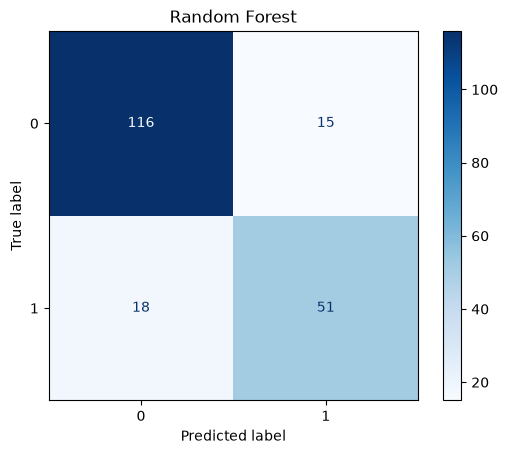

In [83]:
plot_confusion_matrix(
    y_test,
    grid_pred,
    "Random Forest"
)

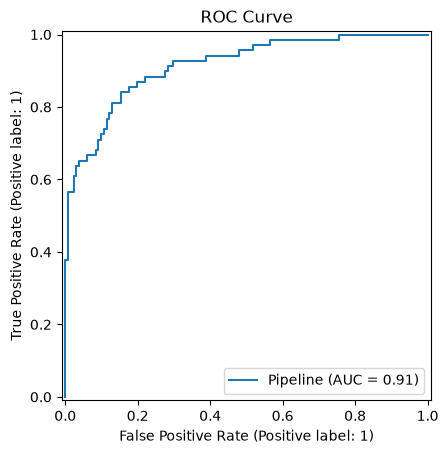

In [84]:
plot_roc_curve(
    best_rf,
    X_test,
    y_test
)

In [85]:
feature_names = best_rf.named_steps[
    "preprocessor"
].get_feature_names_out()

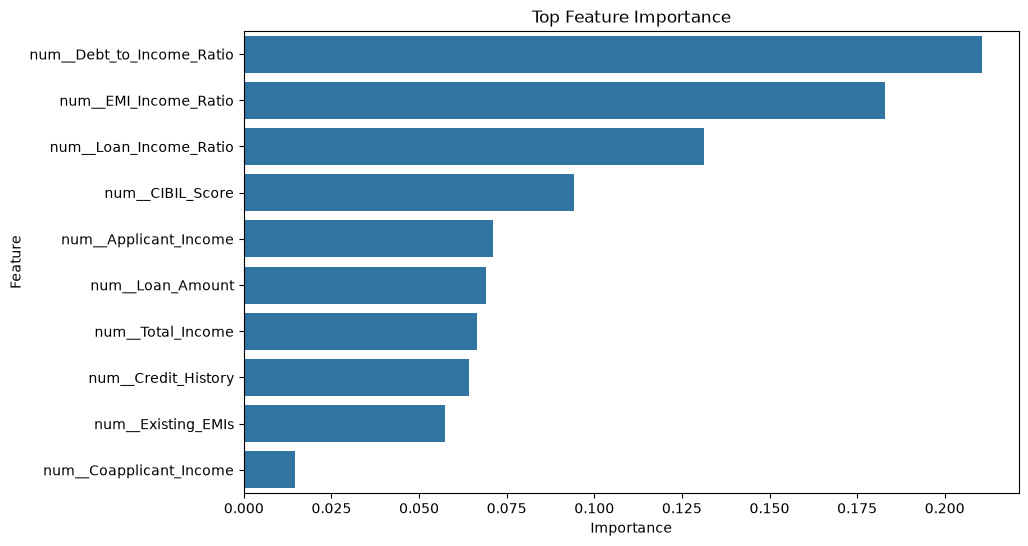

,Feature,Importance
6,num__Debt_to_Income_Ratio,0.210623
9,num__EMI_Income_Ratio,0.182839
8,num__Loan_Income_Ratio,0.131190
4,num__CIBIL_Score,0.094186
0,num__Applicant_Income,0.071187
2,num__Loan_Amount,0.069237
7,num__Total_Income,0.066406
3,num__Credit_History,0.064278
5,num__Existing_EMIs,0.057365
1,num__Coapplicant_Income,0.014597


In [86]:
plot_feature_importance(
    best_rf,
    feature_names
)

In [87]:
joblib.dump(
    best_rf,
    "../models/loan_approval_model.pkl"
)

['../models/loan_approval_model.pkl']